In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
# 1. Load Student Performance dataset
df = pd.read_csv('Student_Performance.csv')

print(df.head())
print('\nDataset Shape:', df.shape)

   Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0              7               99                           1            9   
1              4               82                           0            4   
2              8               51                           1            7   
3              5               52                           1            5   
4              7               75                           0            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1                 91  
1                                 2                 64  
2                                 2                 45  
3                                 2                 37  
4                                 5                 67  

Dataset Shape: (10000, 6)


In [8]:
# 2. Select input features and target
X = df[['Hours Studied',
        'Previous Scores',
        'Extracurricular Activities',
        'Sleep Hours',
        'Sample Question Papers Practiced']]

y = df['Performance Index']

print('Input Features:')
print(X.head())

print('\n Target:')
print(y.head())

Input Features:
   Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0              7               99                           1            9   
1              4               82                           0            4   
2              8               51                           1            7   
3              5               52                           1            5   
4              7               75                           0            8   

   Sample Question Papers Practiced  
0                                 1  
1                                 2  
2                                 2  
3                                 2  
4                                 5  

 Target:
0    91
1    64
2    45
3    37
4    67
Name: Performance Index, dtype: int64


In [11]:
# 3. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training data:', X_train.shape)
print('Testing data:', X_test.shape)

Training data: (8000, 5)
Testing data: (2000, 5)


In [12]:
# 4. Transform data into polynomial features (degree 3)
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print('Original Features:', X_train.shape[1])
print('Polynomial Features:', X_train_poly.shape[1])

Original Features: 5
Polynomial Features: 56


In [13]:
# 5. Train the Linear Regression model on polynomial data
model = LinearRegression()
model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](56,)","[-0. , 0.04, 0.04,...,-0. , 0. , 0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-7.147
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,56
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(43)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](56,)","[23929494.56, 1480681.14, 1336471.55,..., 0. , 0. , 0. ]"


In [14]:
# 6. Predict Performance Index
y_pred = model.predict(X_test_poly)

print('First 10 Predictions:')
print(y_pred[:10])

First 10 Predictions:
[54.25472055 22.72338567 47.49007179 30.80178415 42.24352226 58.29939464
 45.02943344 85.83209776 37.20619155 72.28617373]


In [15]:
# 7. Check model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Mean Squared Error:', mse)
print('R2 Score:', r2)

Mean Squared Error: 2.53756376862016
R2 Score: 0.9930795094780857


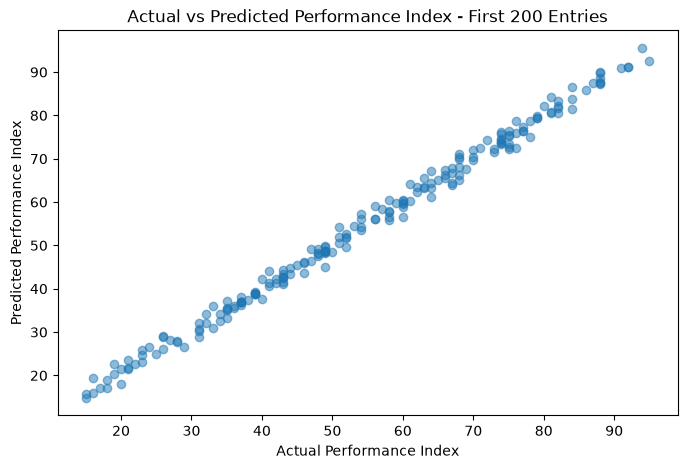

In [17]:
# 8. Plot Actual vs Predicted Performance Index (First 200 Entries)
plt.figure(figsize=(8, 5))
plt.scatter(y_test[:200], y_pred[:200], alpha=0.5)
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.title('Actual vs Predicted Performance Index - First 200 Entries')
plt.show()

c:\Users\MyPC\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


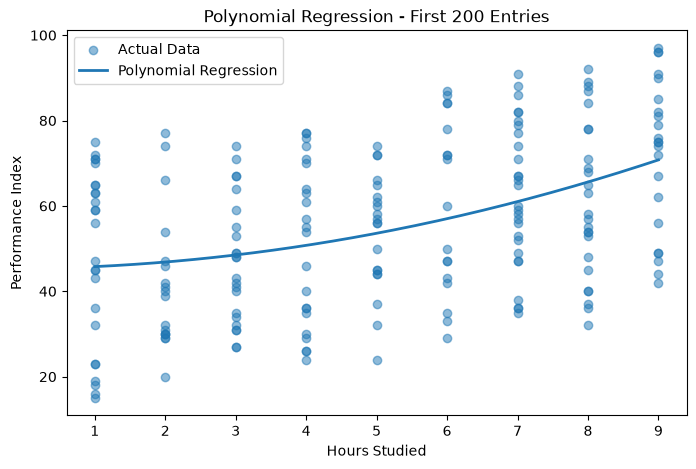

In [20]:
# 8. Plot Polynomial Regression Curve - First 200 Entries

# Use only first 200 entries
X_graph = df[['Hours Studied']].iloc[:200]
y_graph = df['Performance Index'].iloc[:200]

# Create polynomial features
poly_graph = PolynomialFeatures(degree=2)
X_graph_poly = poly_graph.fit_transform(X_graph)

# Train polynomial regression model
model_graph = LinearRegression()
model_graph.fit(X_graph_poly, y_graph)

# Create smooth X values for curve
X_curve = np.linspace(
    X_graph['Hours Studied'].min(),
    X_graph['Hours Studied'].max(),
    200
).reshape(-1, 1)

# Predict curve
X_curve_poly = poly_graph.transform(X_curve)
y_curve = model_graph.predict(X_curve_poly)

# Plot
plt.figure(figsize=(8, 5))

plt.scatter(
    X_graph['Hours Studied'],
    y_graph,
    alpha=0.5,
    label='Actual Data'
)

plt.plot(
    X_curve,
    y_curve,
    linewidth=2,
    label='Polynomial Regression'
)

plt.xlabel('Hours Studied')
plt.ylabel('Performance Index')
plt.title('Polynomial Regression - First 200 Entries')
plt.legend()
plt.show()